1/5: Cargando datos y convirtiendo unidades (kg m-2 s-1 -> mm/día)...
2/5: Extrayendo y suavizando datos para Santiago...
3/5: Calculando Análisis de Sensibilidad (Histórico vs Futuro)...


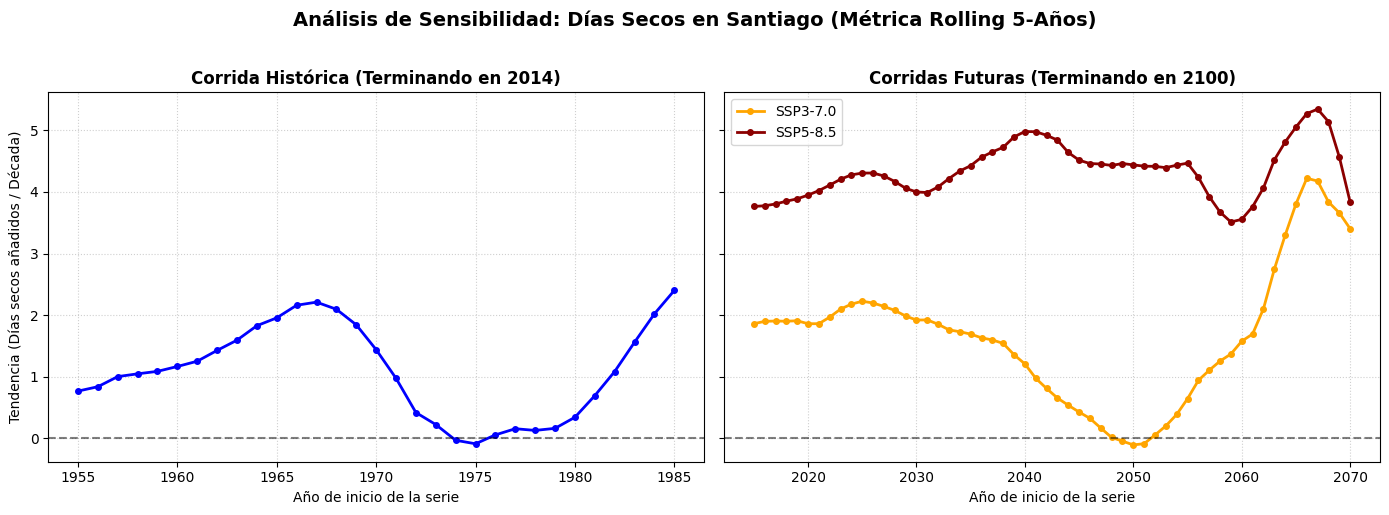

4/5: Calculando Mapas Espaciales 2D (Histórico y Futuro, esto tomará un par de minutos)...


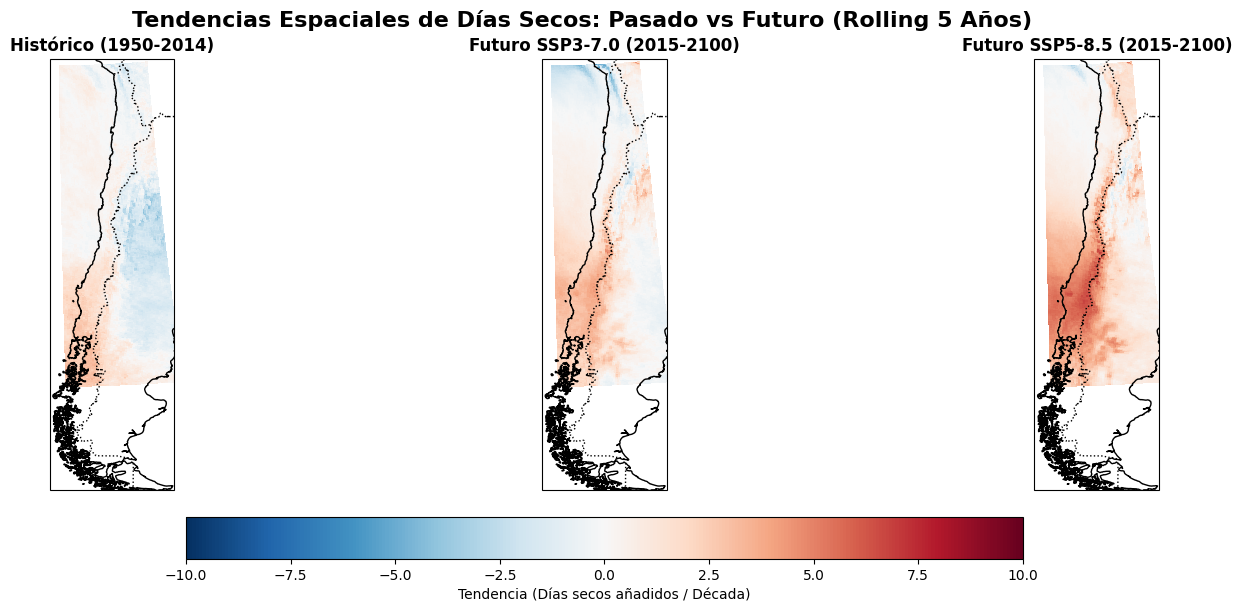

5/5: Calculando Bootstrapping para PDF (Esto tomará unos segundos)...
-> Rachas secas (Dry Spells) encontradas - Histórico: 1355
-> Rachas secas (Dry Spells) encontradas - Futuro SSP5-8.5: 1089


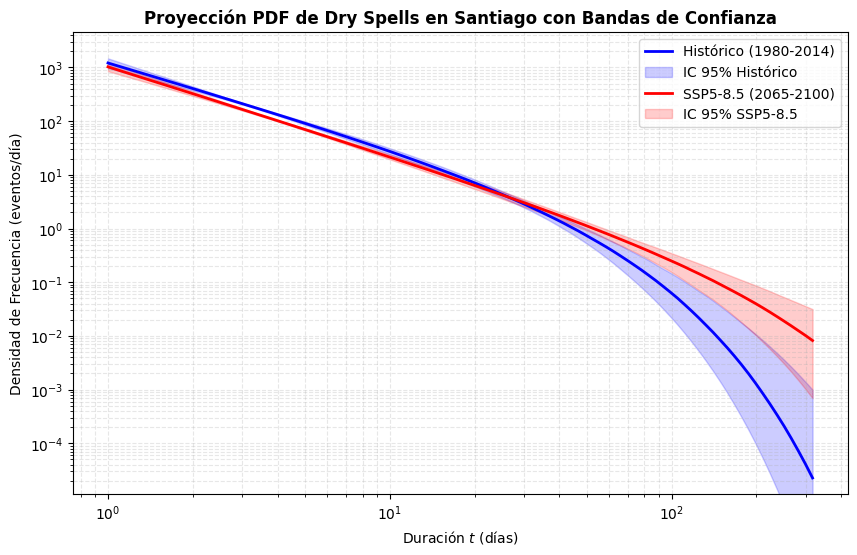

¡Análisis y gráficos finalizados exitosamente!


In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress
import warnings

warnings.filterwarnings('ignore')

# =====================================================================
# 1. CARGA, UNIÓN DE DATOS Y CONVERSIÓN DE UNIDADES
# =====================================================================
print("1/5: Cargando datos y convirtiendo unidades (kg m-2 s-1 -> mm/día)...")
ds_hist = xr.open_mfdataset('./pr1/pr_CHP12_*_historical_*.nc', use_cftime=True, chunks={'time': 365})
ds_ssp370 = xr.open_mfdataset('./pr1/pr_CHP12_*_ssp370_*.nc', use_cftime=True, chunks={'time': 365})
ds_ssp585 = xr.open_mfdataset('./pr1/pr_CHP12_*_ssp585_*.nc', use_cftime=True, chunks={'time': 365})

ds_full_370 = xr.concat([ds_hist, ds_ssp370], dim='time')
ds_full_585 = xr.concat([ds_hist, ds_ssp585], dim='time')

# --- LA SOLUCIÓN AL PROBLEMA ---
# Multiplicamos por 86400 para pasar todo el dataset a mm/día 
ds_full_370['pr'] = ds_full_370['pr'] * 86400
ds_full_585['pr'] = ds_full_585['pr'] * 86400

umbral_pr = 1.0

# =====================================================================
# 2. EXTRACCIÓN DEL PUNTO DE SANTIAGO Y MÉTRICA ROLLING
# =====================================================================
print("2/5: Extrayendo y suavizando datos para Santiago...")
lat_sc, lon_sc = -33.45, -70.66

# Calcular distancia (ALADIN usa grillas proyectadas)
distancia = (ds_full_370['lat'] - lat_sc)**2 + (ds_full_370['lon'] - lon_sc)**2

santiago_diario_370 = ds_full_370.where(distancia == distancia.min(), drop=True).squeeze()
santiago_diario_585 = ds_full_585.where(distancia == distancia.min(), drop=True).squeeze()

def calc_rolling_metric(ds_data):
    dry_days_annual = (ds_data['pr'] < umbral_pr).groupby('time.year').sum('time')
    return dry_days_annual.rolling(year=5, center=True).mean()

sc_370 = calc_rolling_metric(santiago_diario_370).dropna('year').compute()
sc_585 = calc_rolling_metric(santiago_diario_585).dropna('year').compute()

# =====================================================================
# 3. ANÁLISIS 1D: SENSIBILIDAD HISTÓRICA VS FUTURA EN SANTIAGO
# =====================================================================
print("3/5: Calculando Análisis de Sensibilidad (Histórico vs Futuro)...")

# --- PARTE A: CORRIDA HISTÓRICA (Termina en 2014) ---
# Evaluamos años de inicio entre 1955 y 1985 (dejando siempre al menos ~30 años de datos hasta 2014)
anios_inicio_hist = range(1955, 1986) 
tendencias_hist = []

for anio in anios_inicio_hist:
    # Usamos sc_585, pero al cortar hasta 2014, es puramente histórico 
    # (recuerda que el periodo histórico es idéntico en todos los escenarios)
    serie_hist = sc_585.sel(year=slice(anio, 2014))
    slope, _, _, _, _ = linregress(serie_hist.year, serie_hist.values)
    tendencias_hist.append(slope * 10)

# --- PARTE B: CORRIDAS FUTURAS (Comienzan desde 2015, terminan en 2100) ---
# Evaluamos años de inicio entre 2015 y 2070 
anios_inicio_fut = range(2015, 2071)
tendencias_fut_370 = []
tendencias_fut_585 = []

for anio in anios_inicio_fut:
    serie_370 = sc_370.sel(year=slice(anio, 2100))
    serie_585 = sc_585.sel(year=slice(anio, 2100))
    
    slope_370, _, _, _, _ = linregress(serie_370.year, serie_370.values)
    slope_585, _, _, _, _ = linregress(serie_585.year, serie_585.values)
    
    tendencias_fut_370.append(slope_370 * 10)
    tendencias_fut_585.append(slope_585 * 10)

# --- GRAFICAR LOS RESULTADOS SEPARADOS ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Panel 1: Histórico
axes[0].plot(anios_inicio_hist, tendencias_hist, color='blue', lw=2, marker='o', markersize=4)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title("Corrida Histórica (Terminando en 2014)", fontweight='bold')
axes[0].set_xlabel("Año de inicio de la serie")
axes[0].set_ylabel("Tendencia (Días secos añadidos / Década)")
axes[0].grid(True, ls=":", alpha=0.6)

# Panel 2: Futuro
axes[1].plot(anios_inicio_fut, tendencias_fut_370, label='SSP3-7.0', color='orange', lw=2, marker='o', markersize=4)
axes[1].plot(anios_inicio_fut, tendencias_fut_585, label='SSP5-8.5', color='darkred', lw=2, marker='o', markersize=4)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title("Corridas Futuras (Terminando en 2100)", fontweight='bold')
axes[1].set_xlabel("Año de inicio de la serie")
axes[1].legend()
axes[1].grid(True, ls=":", alpha=0.6)

plt.suptitle("Análisis de Sensibilidad: Días Secos en Santiago (Métrica Rolling 5-Años)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. MAPAS ESPACIALES DE TENDENCIA (HISTÓRICO VS FUTUROS)
# =====================================================================
print("4/5: Calculando Mapas Espaciales 2D (Histórico y Futuro, esto tomará un par de minutos)...")

# Definir los periodos
hist_start, hist_end = 1950, 2014
future_start, future_end = 2015, 2100

# 1. Extraer los periodos (Usamos ds_full_585 para el histórico, ya que hasta 2014 es idéntico al 370)
mapa_hist = calc_rolling_metric(ds_full_585).sel(year=slice(hist_start, hist_end))
mapa_fut_370 = calc_rolling_metric(ds_full_370).sel(year=slice(future_start, future_end))
mapa_fut_585 = calc_rolling_metric(ds_full_585).sel(year=slice(future_start, future_end))

# 2. Calcular el ajuste lineal espacial (polyfit) para cada uno
slope_hist = mapa_hist.polyfit(dim='year', deg=1)['polyfit_coefficients'].sel(degree=1) * 10
slope_fut_370 = mapa_fut_370.polyfit(dim='year', deg=1)['polyfit_coefficients'].sel(degree=1) * 10
slope_fut_585 = mapa_fut_585.polyfit(dim='year', deg=1)['polyfit_coefficients'].sel(degree=1) * 10

# 3. Volver a pegar las coordenadas geográficas (para que no falle el pcolormesh)
slope_hist = slope_hist.assign_coords(lon=ds_full_585.lon, lat=ds_full_585.lat)
slope_fut_370 = slope_fut_370.assign_coords(lon=ds_full_370.lon, lat=ds_full_370.lat)
slope_fut_585 = slope_fut_585.assign_coords(lon=ds_full_585.lon, lat=ds_full_585.lat)

# 4. Descargar a memoria para graficar rápido
slope_hist_c = slope_hist.compute()
slope_fut_370_c = slope_fut_370.compute()
slope_fut_585_c = slope_fut_585.compute()

# 5. Graficar los 3 mapas
fig, axes = plt.subplots(1, 3, figsize=(18, 7), subplot_kw={'projection': ccrs.PlateCarree()})
escenarios_mapas = [
    ('Histórico (1950-2014)', slope_hist_c),
    ('Futuro SSP3-7.0 (2015-2100)', slope_fut_370_c), 
    ('Futuro SSP5-8.5 (2015-2100)', slope_fut_585_c)
]

for ax, (titulo, data_mapa) in zip(axes, escenarios_mapas):
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([-76, -65, -55, -17]) # Dominio geográfico de Chile
    
    # Mantenemos la misma escala cromática (-10 a +10) para comparación justa
    im = data_mapa.plot.pcolormesh(ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(), 
                                   cmap='RdBu_r', vmin=-10, vmax=10, add_colorbar=False)
    ax.set_title(titulo, fontweight='bold', fontsize=12)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.6, pad=0.05)
cbar.set_label('Tendencia (Días secos añadidos / Década)')
plt.suptitle("Tendencias Espaciales de Días Secos: Pasado vs Futuro (Rolling 5 Años)", fontsize=16, fontweight='bold', y=0.95)
plt.show()

# =====================================================================
# 5. BOOTSTRAPPING PDF DE DRY SPELLS (SANTIAGO)
# =====================================================================
print("5/5: Calculando Bootstrapping para PDF (Esto tomará unos segundos)...")

def get_spell_durations(ds_diario, start_yr, end_yr):
    pr_slice = ds_diario['pr'].sel(time=slice(f"{start_yr}-01-01", f"{end_yr}-12-31"))
    vals = pr_slice.values
    # Ya está convertido a mm/día globalmente, aplicamos umbral directo
    is_dry = (vals < umbral_pr).astype(int)
    
    x = np.r_[0, is_dry, 0]
    dx = np.diff(x)
    starts = np.where(dx == 1)[0]
    ends = np.where(dx == -1)[0]
    durations = ends - starts
    return durations[durations > 0]

spells_hist = get_spell_durations(santiago_diario_585, 1980, 2014)
spells_fut  = get_spell_durations(santiago_diario_585, 2065, 2100)

print(f"-> Rachas secas (Dry Spells) encontradas - Histórico: {len(spells_hist)}")
print(f"-> Rachas secas (Dry Spells) encontradas - Futuro SSP5-8.5: {len(spells_fut)}")

t_eval = np.logspace(0, 2.5, 100)

def bootstrap_pdf_curves(data, n_iter=1000):
    curves = []
    if len(data) < 10:
        return np.zeros_like(t_eval), np.zeros_like(t_eval), np.zeros_like(t_eval)
        
    for _ in range(n_iter):
        sample = np.random.choice(data, size=len(data), replace=True)
        
        bins = np.logspace(np.log10(min(sample)), np.log10(max(sample)), 20)
        counts, bin_edges = np.histogram(sample, bins=bins)
        bin_widths = np.diff(bin_edges)
        density = counts / bin_widths 
        bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
        
        valid = density > 0
        if sum(valid) < 3: continue
            
        x_val, y_val = bin_centers[valid], density[valid]
        Y = np.log(y_val)
        X_matrix = np.column_stack((np.ones(len(x_val)), np.log(x_val), x_val))
        
        try:
            c, _, _, _ = np.linalg.lstsq(X_matrix, Y, rcond=None)
            c1, c2, c3 = c
            
            # Filtro matemático: Forzamos decaimiento (c3 < 0) y ley de potencia (c2 < 0)
            if c3 < 0 and c2 < 0:
                tau = -c2
                tL = -1.0 / c3
                A = np.exp(c1)
                curve = A * (t_eval**(-tau)) * np.exp(-t_eval/tL)
                curves.append(curve)
        except:
            continue
            
    if len(curves) == 0:
        return np.zeros_like(t_eval), np.zeros_like(t_eval), np.zeros_like(t_eval)
        
    curves = np.array(curves)
    return np.percentile(curves, 2.5, axis=0), np.median(curves, axis=0), np.percentile(curves, 97.5, axis=0)

b_low_h, b_med_h, b_high_h = bootstrap_pdf_curves(spells_hist, 1000)
b_low_f, b_med_f, b_high_f = bootstrap_pdf_curves(spells_fut, 1000)

plt.figure(figsize=(10, 6))

# Trazado Histórico
plt.plot(t_eval, b_med_h, color='blue', lw=2, label='Histórico (1980-2014)')
plt.fill_between(t_eval, b_low_h, b_high_h, color='blue', alpha=0.2, label='IC 95% Histórico')

# Trazado Futuro Lejano SSP5-8.5
plt.plot(t_eval, b_med_f, color='red', lw=2, label='SSP5-8.5 (2065-2100)')
plt.fill_between(t_eval, b_low_f, b_high_f, color='red', alpha=0.2, label='IC 95% SSP5-8.5')

plt.xscale('log')
plt.yscale('log')
plt.title("Proyección PDF de Dry Spells en Santiago con Bandas de Confianza", fontweight='bold')
plt.xlabel("Duración $t$ (días)")
plt.ylabel("Densidad de Frecuencia (eventos/día)")

# Ajuste automático del eje Y para evitar graficar zonas vacías
valid_h = b_med_h[b_med_h > 0]
valid_f = b_med_f[b_med_f > 0]
if len(valid_h) > 0 and len(valid_f) > 0:
    plt.ylim(bottom=min(np.min(valid_h), np.min(valid_f)) * 0.5)

plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

print("¡Análisis y gráficos finalizados exitosamente!")

6/6: Calculando Mapas de Delta Porcentual...


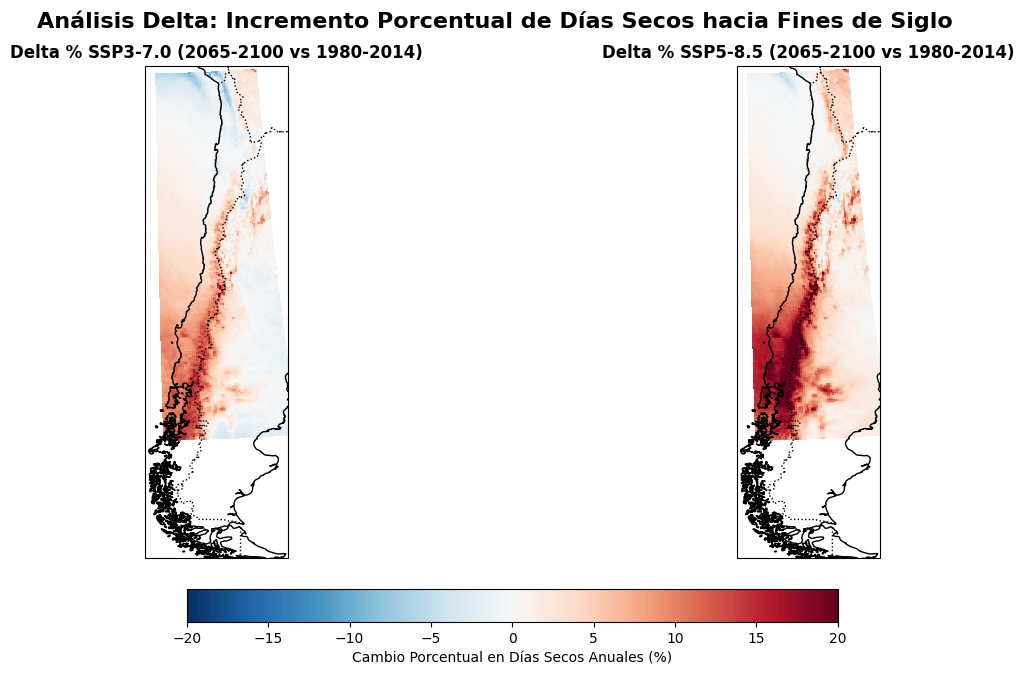

¡Mapas Delta generados con éxito!


In [3]:
# =====================================================================
# 6. MAPAS DE DELTA PORCENTUAL (FUTURO vs HISTÓRICO)
# =====================================================================
print("6/6: Calculando Mapas de Delta Porcentual...")

# Definir periodos a comparar
periodo_hist = slice(1980, 2014)
periodo_fut = slice(2065, 2100) # Usamos el futuro lejano para ver el impacto máximo

# Calcular los promedios temporales de la métrica suavizada (5-year rolling)
# Extraemos los datos a memoria con .compute() para graficar rápido
mean_hist = calc_rolling_metric(ds_full_585).sel(year=periodo_hist).mean(dim='year').compute()

mean_fut_370 = calc_rolling_metric(ds_full_370).sel(year=periodo_fut).mean(dim='year').compute()
mean_fut_585 = calc_rolling_metric(ds_full_585).sel(year=periodo_fut).mean(dim='year').compute()

# Calcular el Delta Porcentual: ((Futuro - Historico) / Historico) * 100
delta_pct_370 = ((mean_fut_370 - mean_hist) / mean_hist) * 100
delta_pct_585 = ((mean_fut_585 - mean_hist) / mean_hist) * 100

# Pegar coordenadas geográficas para evitar errores en pcolormesh
delta_pct_370 = delta_pct_370.assign_coords(lon=ds_full_370.lon, lat=ds_full_370.lat)
delta_pct_585 = delta_pct_585.assign_coords(lon=ds_full_585.lon, lat=ds_full_585.lat)

# Configurar el lienzo de los mapas
fig, axes = plt.subplots(1, 2, figsize=(14, 8), subplot_kw={'projection': ccrs.PlateCarree()})
escenarios_delta = [('Delta % SSP3-7.0 (2065-2100 vs 1980-2014)', delta_pct_370), 
                    ('Delta % SSP5-8.5 (2065-2100 vs 1980-2014)', delta_pct_585)]

for ax, (titulo, data_delta) in zip(axes, escenarios_delta):
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([-76, -65, -55, -17]) # Dominio de Chile
    
    # Usamos cmap='RdBu_r': Rojo indica aumento de días secos (+%), Azul indica disminución (-%)
    # Fijamos vmin y vmax en +/- 20% para resaltar bien los cambios, puedes ajustarlo si lo necesitas
    im = data_delta.plot.pcolormesh(ax=ax, x='lon', y='lat', transform=ccrs.PlateCarree(), 
                                    cmap='RdBu_r', vmin=-20, vmax=20, add_colorbar=False)
    ax.set_title(titulo, fontweight='bold', fontsize=12)

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', shrink=0.6, pad=0.05)
cbar.set_label('Cambio Porcentual en Días Secos Anuales (%)')
plt.suptitle("Análisis Delta: Incremento Porcentual de Días Secos hacia Fines de Siglo", fontsize=16, fontweight='bold', y=0.95)
plt.show()

print("¡Mapas Delta generados con éxito!")